In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import confusion_matrix
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load data
with open('data/processed/data_splits.pkl', 'rb') as f:
    data = pickle.load(f)

classes = data['classes']
test_paths = data['test_paths']
test_labels = data['test_labels']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, len(classes))
model.load_state_dict(torch.load('models/resnet50_balanced.pth', map_location='cpu'))
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Everything loaded!")

Everything loaded!


In [2]:
print("Finding misclassified images...")

misclassified = []
all_preds = []
all_true = []

with torch.inference_mode():
    for i, (img_path, true_label) in enumerate(zip(test_paths, test_labels)):
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = probs.max(1)
        
        pred_label = pred.item()
        confidence = conf.item()
        
        all_preds.append(pred_label)
        all_true.append(true_label)
        
        if pred_label != true_label:
            misclassified.append({
                'path': img_path,
                'true': true_label,
                'true_name': classes[true_label],
                'pred': pred_label,
                'pred_name': classes[pred_label],
                'confidence': confidence
            })
        
        if (i+1) % 500 == 0:
            print(f"  Processed {i+1}/{len(test_paths)} images...")

print(f"\nTotal test images:     {len(test_paths)}")
print(f"Correctly classified:  {len(test_paths) - len(misclassified)}")
print(f"Misclassified:         {len(misclassified)}")
print(f"Error rate:            {len(misclassified)/len(test_paths)*100:.2f}%")

Finding misclassified images...
  Processed 500/3096 images...
  Processed 1000/3096 images...
  Processed 1500/3096 images...
  Processed 2000/3096 images...
  Processed 2500/3096 images...
  Processed 3000/3096 images...

Total test images:     3096
Correctly classified:  3088
Misclassified:         8
Error rate:            0.26%


In [3]:
print("Misclassified images breakdown:\n")
for i, m in enumerate(misclassified):
    print(f"Error {i+1}:")
    print(f"  True:      {m['true_name']}")
    print(f"  Predicted: {m['pred_name']}")
    print(f"  Confidence: {m['confidence']*100:.2f}%")
    print()

Misclassified images breakdown:

Error 1:
  True:      Tomato_Early_blight
  Predicted: Potato___Late_blight
  Confidence: 96.88%

Error 2:
  True:      Tomato__Target_Spot
  Predicted: Tomato_Spider_mites_Two_spotted_spider_mite
  Confidence: 64.11%

Error 3:
  True:      Tomato__Target_Spot
  Predicted: Tomato_Early_blight
  Confidence: 52.80%

Error 4:
  True:      Pepper__bell___healthy
  Predicted: Tomato_Late_blight
  Confidence: 69.54%

Error 5:
  True:      Tomato_Late_blight
  Predicted: Tomato_Early_blight
  Confidence: 57.84%

Error 6:
  True:      Pepper__bell___healthy
  Predicted: Pepper__bell___Bacterial_spot
  Confidence: 77.28%

Error 7:
  True:      Tomato_Late_blight
  Predicted: Tomato_Early_blight
  Confidence: 99.66%

Error 8:
  True:      Tomato_Bacterial_spot
  Predicted: Tomato_Early_blight
  Confidence: 91.65%



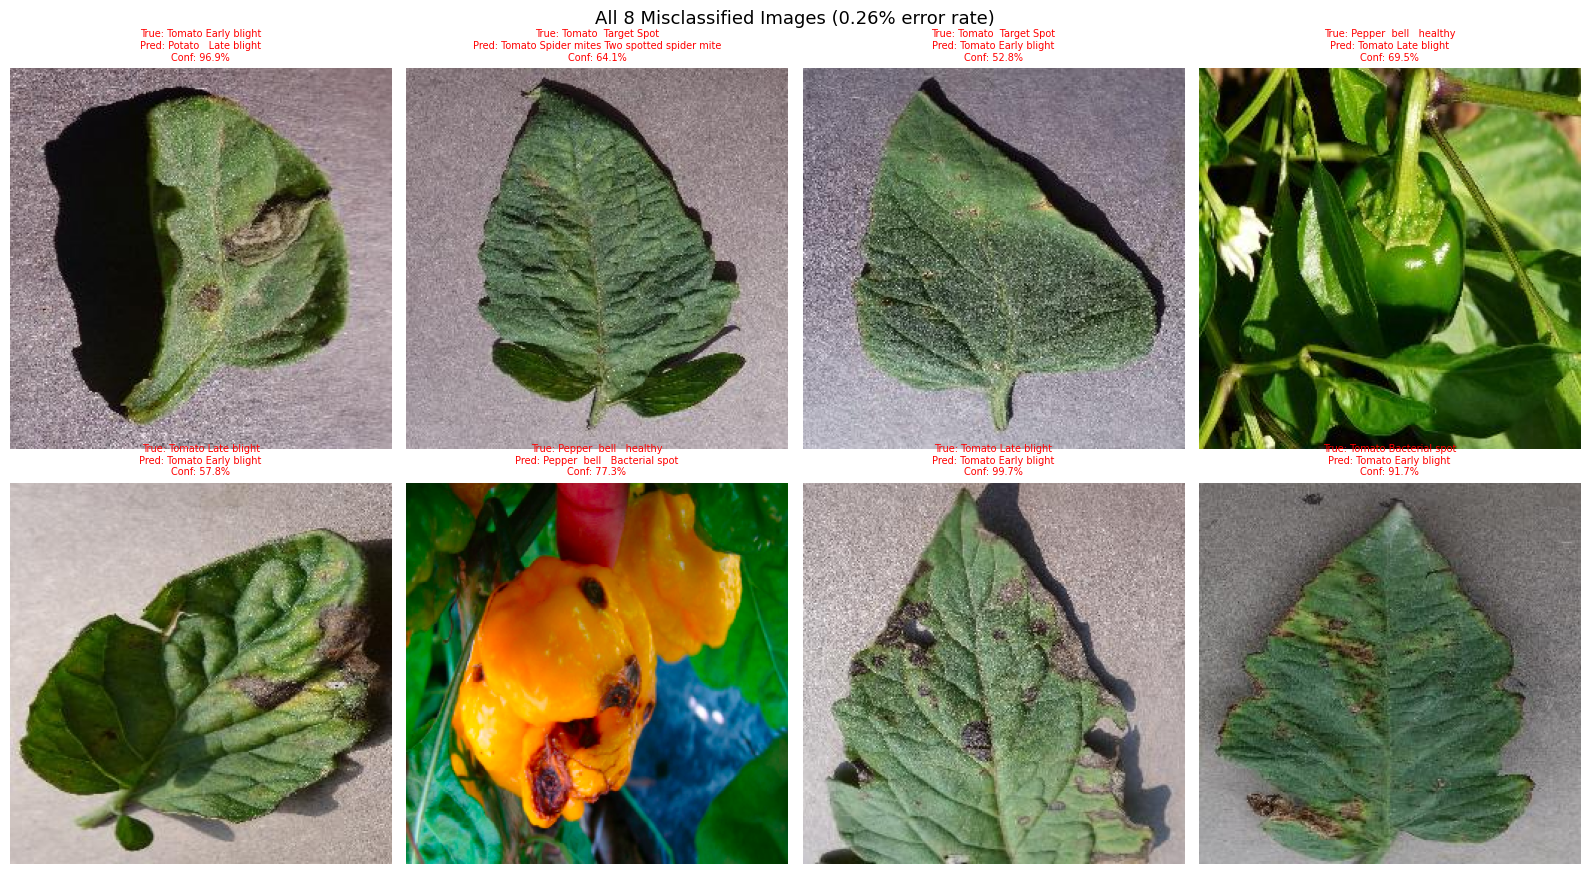

Saved to outputs/misclassified_images.png


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, m in enumerate(misclassified):
    img = Image.open(m['path']).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {m['true_name'].replace('_',' ')}\n"
        f"Pred: {m['pred_name'].replace('_',' ')}\n"
        f"Conf: {m['confidence']*100:.1f}%",
        fontsize=7, color='red'
    )
    axes[i].axis('off')

plt.suptitle('All 8 Misclassified Images (0.26% error rate)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/misclassified_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/misclassified_images.png")